<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Use Natural Language to Create Charts and Graphs**
## **Build Your Own Data Visualization Agent**


Estimated time needed: **30** minutes


## Overview


Imagine you are a data analyst or a data scientist of a marketing team at an e-commerce company. The company needs to understand customer purchasing behaviors over the last year to tailor their upcoming holiday campaigns. Traditionally, this would involve complex SQL queries, data wrangling in Python, and perhaps building visual dashboards to interpret the results including analyzing spreadsheets, creating charts, and maybe even some statistical analysis—tasks that require considerable time and expertise.

With the integration of Langchain and LLMs, you can simply ask, "Show me a visualization of monthly sales trends by product category," or "Generate a heatmap of customer activity by region." The system would use the `create_pandas_dataframe_agent` to process the CSV data, and then dynamically generate visualizations such as line graphs, bar charts, or heatmaps in response to these queries. This not only speeds up the data analysis process but also allows team members who may not be tech-savvy to engage directly with the data and make informed decisions quickly. This approach fosters a more collaborative environment and ensures that strategic decisions are backed by real-time data insights, visually represented for easy comprehension.

<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/V_7__WU_jHJ1lOpTeSLxTQ/chat%20with%20data.png" width="50%" alt="indexing"/>


In this lab, you will learn how to seamlessly integrate data visualization into your conversational data analysis using Langchain and LLMs. Starting with CSV file data, you will use the `create_pandas_dataframe_agent` to build an interactive agent that not only understands and responds to your queries but also translates data responses into visual formats. You will explore how to dynamically generate charts, graphs, and heatmaps directly in response to natural language questions. This capability will enable you to visualize trends, compare figures, and spot patterns immediately, making your data analysis workflow both efficient and visually engaging. By the end of this project, you will have the skills to create a data conversational agent that acts as both analyst and visualizer, bringing data to life through dialogue.

In this lab, you are going to use an OpenAI chat model through LangChain v1. The OpenAI API key is loaded from the repository-level `.env` file.


---------


## __Table of contents__

<ol>
    <li><a href="#Overview">Overview</a></li>
    <li><a href="#Objectives">Objectives</a></li>
    <li>
        <a href="#Setup">Setup</a>
        <ol>
            <li><a href="#Installing-required-libraries">Installing required libraries</a></li>
            <li><a href="#Importing-required-libraries">Importing required libraries</a></li>
        </ol>
    </li>
    <li>
        <a href="#Data-set">Data set</a>
        <ol>
            <li><a href="#Load-the-data-set">Load the data set</a></li>
        </ol>
    </li>
    <li>
        <a href="#Load-LLM">Load LLM</a>
        <ol>
            <li><a href="#Talk-to-your-data">Talk to your data</a></li>
            <li><a href="#Plot-your-data-with-natural-language">Plot your data with natural language</a></li>
        </ol>
    </li>
</ol>

<a href="#Exercises">Exercises</a>
<ol>
    <li><a href="#Exercise-1---Relationship-between-parental-education-level-and-student-grades">Exercise 1. Relationship between parental education level and student grades</a></li>
    <li><a href="#Exercise-2---Impact-of-internet-access-at-home-on-grades">Exercise 2. Impact of internet access at home on grades</a></li>
    <li><a href="#Exercise-3---Explore-LLM's-code">Exercise 3. Explore LLM's code</a></li>
</ol>


## Objectives


After completing the project, you should be able to:

- **Use LangChain with large language models**: Understand and apply the Langchain framework in conjunction with LLMs to interact with and analyze data stored in CSV files through natural language processing.
- **Create conversational data agents**: Build a conversational agent that can understand and respond to natural language queries about data, enabling users to ask questions directly and receive immediate answers.
- **Implement data visualization through dialogue**: Integrate data visualization tools within your conversational agent, allowing you to request and generate visual data representations such as graphs, charts, and heatmaps dynamically based on your queries.
- **Enhance decision-making process**: Develop the capability to derive actionable insights from data via interactive dialogues and visual outputs, thereby improving the decision-making process and making data analysis accessible to non-technical stakeholders.


----


## Setup


This project is based on Jupyter Notebook. If you're not familiar with it, here's a quick guide on how to run code within it:

A Jupyter Notebook consists of cells. To execute a code cell, click on the cell that you want to run and click the 'Run' button, as shown in the picture.


<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IwbhiH3Wwv-VK-J4rioTAw/run.png" width="50%" alt="indexing"/>


For this lab, you will be using the following libraries:

*   [`python-dotenv`](https://pypi.org/project/python-dotenv/) for loading the repository-level `.env` file.
*   [`LangChain`, `langchain-openai`, `langchain-experimental`](https://www.langchain.com/) for using OpenAI chat models and the pandas DataFrame agent.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for additional plotting tools.
*   [`seaborn`](https://seaborn.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for visualizing the data.


### Installing required libraries

If you are using the `agents` conda environment, the required libraries are already installed and you can skip the following optional install cell.

If you are running this notebook in a different environment, uncomment and run the following cell to install the dependencies:

This might take approximately 1-2 minutes. 

As you use `%%capture` to capture the installation, you won't see the output process. But after the installation completes, you will see a number beside the cell.


In [1]:
"""
%%capture
!pip install --user -U "python-dotenv" "langchain" "langchain-openai" "langchain-experimental" "pandas" "matplotlib" "seaborn" "tabulate"
"""

'\n%%capture\n!pip install --user -U "python-dotenv" "langchain" "langchain-openai" "langchain-experimental" "pandas" "matplotlib" "seaborn" "tabulate"\n'

After you install the libraries in a new environment, restart your kernel. You can do that by clicking the **Restart the kernel** icon.

<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/build-a-hotdog-not-hotdog-classifier-guided-project/images/Restarting_the_Kernel.png" width="50%" alt="Restart kernel">


### Importing required libraries

_It is recommended that you import all required libraries in one place (here):_


In [2]:
# You can use this section to suppress warnings generated by your code:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

# Watson imports from the original lab are intentionally commented out.
# from ibm_watsonx_ai.foundation_models import Model
# from ibm_watsonx_ai.metanames import GenTextParamsMetaNames as GenParams
# from ibm_watson_machine_learning.foundation_models.extensions.langchain import WatsonxLLM

from pathlib import Path
import os

from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_experimental.agents import create_pandas_dataframe_agent

import matplotlib.pyplot as plt
import pandas as pd

## Dataset


In this lab, you will work on the Student Alcohol Consumption data set `student-mat.csv` by UCI Machine Learning as an example. For more information, see [Kaggle](https://www.kaggle.com/datasets/uciml/student-alcohol-consumption). It is based on data collected from two secondary schools in Portugal. The students included in the survey were in mathematics and Portuguese courses.


The dataset you are using is for the mathematics course. The number of mathematics students involved in the collection was 395. The data collected in locations such as Gabriel Pereira and Mousinho da Silveira includes several pertinent values. Examples of such data are records of demographic information, grades, and alcohol consumption.


| Field     | Description                                                                 |
|-----------|-----------------------------------------------------------------------------|
| school    | GP/MS for the student's school                                              |
| sex       | M/F for gender                                                              |
| age       | 15-22 for the student's age                                                 |
| address   | U/R for urban or rural, respectively                                        |
| famsize   | LE3/GT3 for less than or greater than three family members                  |
| Pstatus   | T/A for living together or apart from parents, respectively                 |
| Medu      | 0 (none) / 1 (primary-4th grade) / 2 (5th - 9th grade) / 3 (secondary) / 4 (higher) for mother's education |
| Fedu      | 0 (none) / 1 (primary-4th grade) / 2 (5th - 9th grade) / 3 (secondary) / 4 (higher) for father's education |
| Mjob      | 'teacher,' 'health' care related, civil 'services,' 'at_home' or 'other' for the student's mother's job |
| Fjob      | 'teacher,' 'health' care related, civil 'services,' 'at_home' or 'other' for the student's father's job |
| reason    | reason to choose this school (nominal: close to 'home', school 'reputation', 'course' preference or 'other') |
| guardian  | mother/father/other as the student's guardian                               |
| traveltime| 1 (<15mins) / 2 (15 - 30 mins) / 3 (30 mins - 1 hr) / 4 (>1hr) for a time from home to school |
| studytime | 1 (<2hrs) / 2 (2 - 5hrs) / 3 (5 - 10hrs) / 4 (>10hrs) for weekly study time |
| failures  | 1-3/4 for the number of class failures (if more than three, then record 4)  |
| schoolsup | yes/no for extra educational support                                        |
| famsup    | yes/no for family educational support                                       |
| paid      | yes/no for extra paid classes for Math or Portuguese                        |
| activities| yes/no for extra-curricular activities                                      |
| nursery   | yes/no for whether attended nursery school                                  |
| higher    | yes/no for the desire to continue studies                                   |
| internet  | yes/no for internet access at home                                          |
| romantic  | yes/no for relationship status                                              |
| famrel    | 1-5 scale on quality of family relationships                                |
| freetime  | 1-5 scale on how much free time after school             |
| goout     | 1-5 scale on how much student goes out with friends      |
| Dalc      | 1-5 scale on how much alcohol consumed on weekdays       |
| Walc      | 1-5 scale on how much alcohol consumed on the weekend    |
| health    | 1-5 scale on health condition                            |
| absences  | 0-93 number of absences from school                      |
| G1        | 0-20 for the first-period grade                          |
| G2        | 0-20 for the second-period grade                         |
| G3        | 0-20 for the final grade                                 |


### Load the data set


Execute the code in the following cell to load your dataset. This code reads the CSV file into a pandas DataFrame, making the data accessible for processing in Python.


In [3]:
# To download:
# https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/ZNoKMJ9rssJn-QbJ49kOzA/student-mat.csv
df = pd.read_csv("student-mat.csv")

Let's examine the first five rows of the dataset to get a glimpse of the data structure and its contents.


In [4]:
df.head(5)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


You can also review the detailed information for each column in the dataset, focusing on the presence of null values and the specific data types of each column.


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

## Load LLM


Execute the code in the cell below to load the OpenAI chat model configured in your `.env` file. 

Additionally, you will configure the LLM to interact with data by integrating it with LangChain's `create_pandas_dataframe_agent`.


In [7]:
# Load OpenAI credentials from the repository-level .env file.
# The notebook lives in 01_Fundamentals/lab, so ../.. points to the repo root.
load_dotenv(dotenv_path=Path("../..") / ".env")

if not os.getenv("OPENAI_API_KEY"):
    raise RuntimeError("OPENAI_API_KEY was not found. Add it to ../../.env before running this notebook.")

# Initialize the OpenAI chat model through LangChain v1.
llm = ChatOpenAI(
    model="gpt-4.1-mini",
    temperature=0,
    max_tokens=256,
)

In [8]:
agent = create_pandas_dataframe_agent(
    llm,
    df,
    verbose=False,
    return_intermediate_steps=True,  # set return_intermediate_steps=True so that model could return code that it comes up with to generate the chart
    handle_parsing_errors=True,
    allow_dangerous_code=True,  # Required because the pandas agent executes Python code. Use in a trusted environment only.
)

## API Disclaimer
This lab uses an OpenAI model through LangChain. Your `OPENAI_API_KEY` is loaded from `../../.env`, and API usage may incur charges depending on your OpenAI account.

### Running Locally
If you are running this lab locally, keep a `.env` file at the repository root with `OPENAI_API_KEY=...`. The conda environment `agents` already contains the required libraries.


In [9]:
# Optional check: confirm the key is available without printing the secret.
print("OPENAI_API_KEY loaded:", bool(os.getenv("OPENAI_API_KEY")))

OPENAI_API_KEY loaded: True


### Interact with your data


Let's start with a simple interaction.

Ask LLM how many rows of data are in the CSV file.


In [10]:
response = agent.invoke({"input": "how many rows of data are in this file?"})

In [11]:
response['output']

'There are 395 rows of data in the dataframe.'

From the output above, the model reports that there are 395 rows of data in the file.


Let's verify this count using Python code to ensure accuracy.


In [12]:
len(df)

395

The row count matches and is correct! 


Curious about the code the LLM generated and used to create this result?

Run the code in the cell below to reveal the underlying commands.


In [13]:
response['intermediate_steps'][-1][0].tool_input.replace('; ', '\n')

'df.shape[0]'

Surprisingly, the LLM uses the same code as you do.


Also, you could let LLM return some data that you are looking for based on the CSV file.


In [14]:
response = agent.invoke({"input": "Give me all the data where student's age is over 18 years old."})

In [15]:
print(response)

{'input': "Give me all the data where student's age is over 18 years old.", 'output': "Here is the dataframe filtered to include only students whose age is over 18 years old:\n\n```python\ndf[df['age'] > 18]\n```", 'intermediate_steps': [(AgentAction(tool='python_repl_ast', tool_input="df[df['age'] > 18]", log="Thought: I need to filter the dataframe `df` to include only rows where the `age` column is greater than 18.\n\nAction: python_repl_ast\nAction Input: df[df['age'] > 18]"),     school sex  age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
127     GP   F   19       U     GT3       T     0     1   at_home     other   
153     GP   M   19       U     GT3       T     3     2  services   at_home   
210     GP   F   19       U     GT3       T     3     3     other     other   
247     GP   M   22       U     GT3       T     3     1  services  services   
257     GP   M   19       U     LE3       A     4     3  services   at_home   
270     GP   F   19       U     GT3     

Let's get the code LLM used for charting this plot.


In [16]:
response['intermediate_steps'][-1][0].tool_input.replace('; ', '\n')

"df[df['age'] > 18]"

### Plot your data with natural language


#### Task 1
Generating a first visual on the data set to know the total number of male and female students in the data set.

You just need to tell the agent that "Plot the gender count with bars."


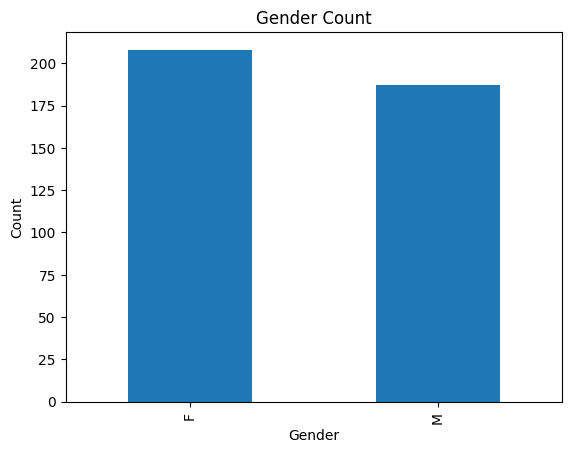

In [17]:
response = agent.invoke({"input": "Generate a bar chart to plot the gender count."})

Let's see what code the LLM generated for ploting this chart.


In [18]:
print(response['intermediate_steps'][-1][0].tool_input.replace('; ', '\n'))

import matplotlib.pyplot as plt

gender_counts = df['sex'].value_counts()
gender_counts.plot(kind='bar')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Gender Count')
plt.show()


#### Task 2

Generating a pie chart to display the average value of weekend alcohol for each gender in the dataset.

You will use the prompt "Generate a pie chart to display the average value of Walc for each gender."

You may notice that the model generates two charts. The charts indicate the progressive improvement of the agent's code as it searches for the best way to answer your prompt, which improves the response to your query.


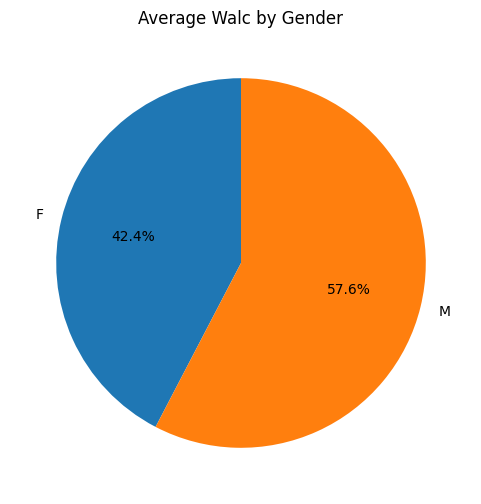

In [19]:
response = agent.invoke({"input": "Generate a pie chart to display average value of Walc for each Gender."})

Let's get the code LLM used for charting this plot.


In [20]:
print(response['intermediate_steps'][-1][0].tool_input.replace('; ', '\n'))

import matplotlib.pyplot as plt

# Calculate average Walc for each gender
avg_walc_by_gender = df.groupby('sex')['Walc'].mean()

# Plot pie chart
plt.figure(figsize=(6,6))
avg_walc_by_gender.plot.pie(autopct='%1.1f%%', startangle=90, legend=False)
plt.title('Average Walc by Gender')
plt.ylabel('')
plt.show()


#### Task 3

You can explore the impact of free time on grades based on the data.


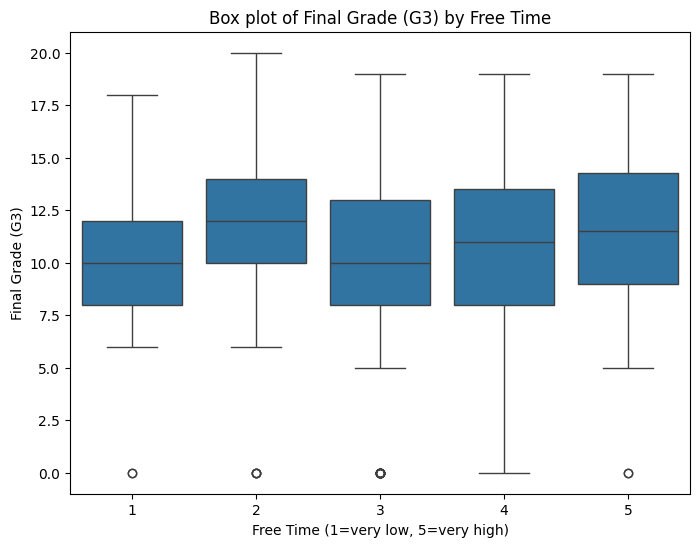

In [21]:
response = agent.invoke({"input": "Create box plots to analyze the relationship between 'freetime' (amount of free time) and 'G3' (final grade) across different levels of free time."})

Execute the code below to retrieve the Python script the LLM used for plotting.


In [22]:
print(response['intermediate_steps'][-1][0].tool_input.replace('; ', '\n'))

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.boxplot(x='freetime', y='G3', data=df)
plt.title('Box plot of Final Grade (G3) by Free Time')
plt.xlabel('Free Time (1=very low, 5=very high)')
plt.ylabel('Final Grade (G3)')
plt.show()



#### Task 4

You can explore the effect of alcohol consumption on academic performance.


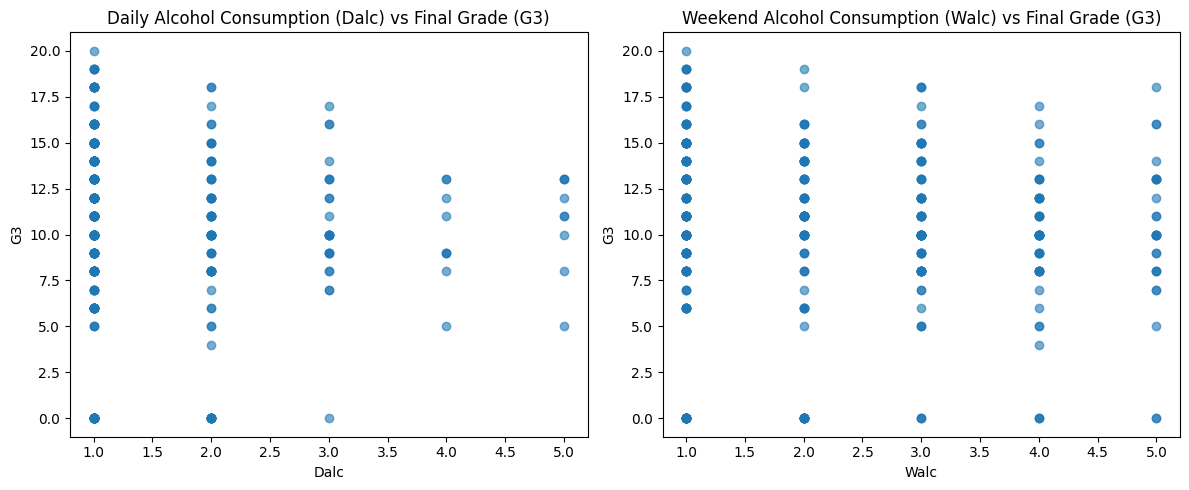

In [23]:
response = agent.invoke({"input": "Generate scatter plots to examine the correlation between 'Dalc' (daily alcohol consumption) and 'G3', and between 'Walc' (weekend alcohol consumption) and 'G3'."})

Execute the code below to retrieve the Python script the LLM used for plotting.


In [24]:
print(response['intermediate_steps'][-1][0].tool_input.replace('; ', '\n'))

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Scatter plot for Dalc vs G3
plt.subplot(1, 2, 1)
plt.scatter(df['Dalc'], df['G3'], alpha=0.6)
plt.title('Daily Alcohol Consumption (Dalc) vs Final Grade (G3)')
plt.xlabel('Dalc')
plt.ylabel('G3')

# Scatter plot for Walc vs G3
plt.subplot(1, 2, 2)
plt.scatter(df['Walc'], df['G3'], alpha=0.6)
plt.title('Weekend Alcohol Consumption (Walc) vs Final Grade (G3)')
plt.xlabel('Walc')
plt.ylabel('G3')

plt.tight_layout()
plt.show()


# Exercises


### Exercise 1 - Relationship between parental education level and student grades


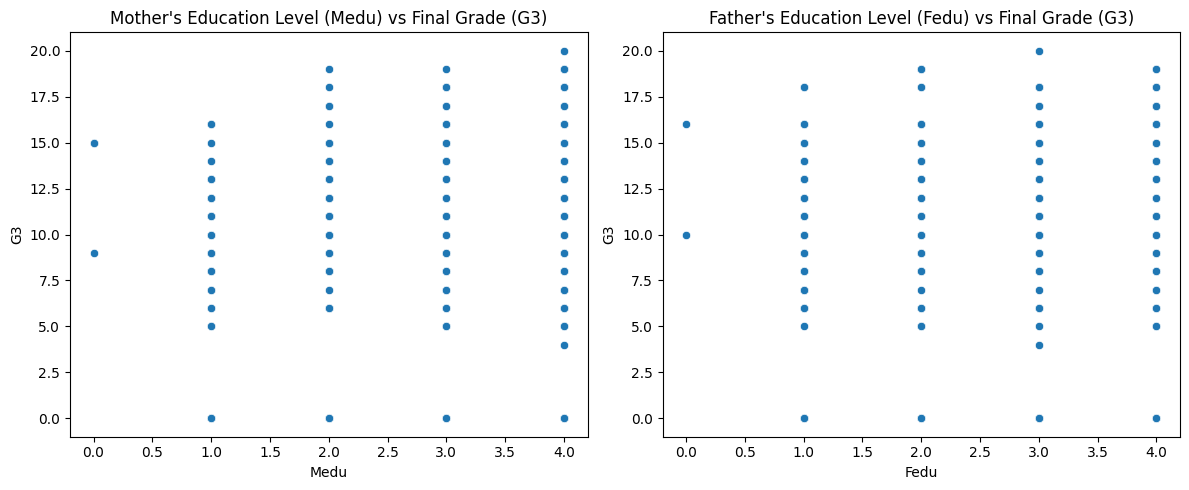

In [26]:
# your code here
response = agent.invoke({
    "input": (
        "Generate scatter plots showing the relationship between "
        "'Medu' (mother's education level) and 'G3' (final grade), "
        "and between 'Fedu' (father's education level) and 'G3'."
    )
})

<details>
    <summary>Click here for Solution</summary>

```python

response = agent.invoke({
    "input": (
        "Generate scatter plots showing the relationship between "
        "'Medu' (mother's education level) and 'G3' (final grade), "
        "and between 'Fedu' (father's education level) and 'G3'."
    )
})

```

</details>


### Exercise 2 - Impact of internet access at home on grades


In [27]:
# your code here
response = agent.invoke({"input": "Use bar plots to compare the average final grades ('G3') of students with internet access at home versus those without ('internet' column)."})

In [28]:
response

{'input': "Use bar plots to compare the average final grades ('G3') of students with internet access at home versus those without ('internet' column).",
 'output': "The average final grades ('G3') for students without internet access is approximately 9.41, and for those with internet access is approximately 10.62. You can use the following code to create a bar plot comparing these averages:\n\n```python\nimport matplotlib.pyplot as plt\nimport seaborn as sns\n\n# Calculate average G3 for students with and without internet access\navg_grades = df.groupby('internet')['G3'].mean().reset_index()\n\n# Plotting the bar plot\nplt.figure(figsize=(8, 6))\nsns.barplot(x='internet', y='G3', data=avg_grades)\nplt.title('Average Final Grades (G3) by Internet Access at Home')\nplt.xlabel('Internet Access at Home')\nplt.ylabel('Average Final Grade (G3)')\nplt.show()\n```",
 'intermediate_steps': [(AgentAction(tool='[python_repl_ast]', tool_input="|\n    import matplotlib.pyplot as plt\n    import sea

<details>
    <summary>Click here for a solution</summary>
    
```python

response = agent.invoke({"input": "Use bar plots to compare the average final grades ('G3') of students with internet access at home versus those without ('internet' column)."})

```

</details>


### Exercise 3 - Explore LLM's code


Can you find what code the model used to generate the plot for exploring the relationship between absences and academic performance?

You could run the corresponding code and from the response chain, you could see the code used from charting.


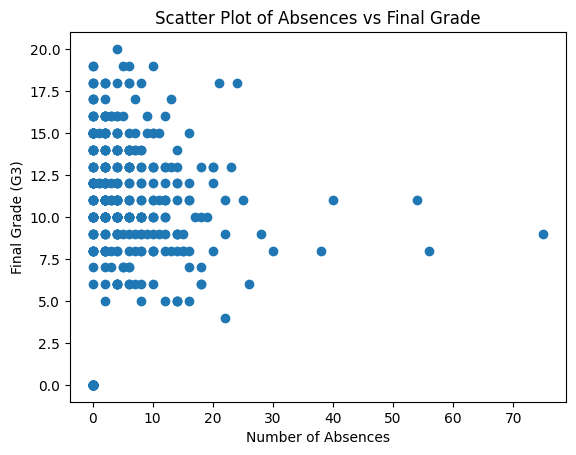

import matplotlib.pyplot as plt

plt.scatter(df['absences'], df['G3'])
plt.xlabel('Number of Absences')
plt.ylabel('Final Grade (G3)')
plt.title('Scatter Plot of Absences vs Final Grade')
plt.show()


In [29]:
# your code here
response = agent.invoke({"input": "Plot a scatter plot showing the correlation between the number of absences ('absences') and final grades ('G3') of students."})

for i in range(len(response['intermediate_steps'])):
    print(response['intermediate_steps'][i][0].tool_input.replace(';', '\n'))

<details>
    <summary>Click here for a solution</summary>
    
```python

response = agent.invoke({"input": "Plot a scatter plot showing the correlation between the number of absences ('absences') and final grades ('G3') of students."})

for i in range(len(response['intermediate_steps'])):
    print(response['intermediate_steps'][i][0].tool_input.replace(';', '\n'))

```

</details>


## Authors


[Kang Wang](https://author.skills.network/instructors/kang_wang)

Kang Wang is a Data Scientist in IBM. He is also a PhD Candidate in the University of Waterloo.


[Wojciech Fulmyk](https://author.skills.network/instructors/wojciech_fulmyk) <br>
Wojciech "Victor" Fulmyk is a Data Scientist at IBM. He is also a PhD Candidate in Economics in the University of Calgary.


## Other contributors


[Ricky Shi](https://author.skills.network/instructors/ricky_shi) <br>
Ricky Shi is a data scientist at the Ecosystems Skills Network at IBM.


<!--## Change Log--!>


<!--|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-05-10|0.2|Kang Wang & Wojciech Fulmyk|Initial version created|
|2024-02-23|0.1|Elio Di Nino|Update library documentation|--!>



## Copyright © IBM Corporation. All rights reserved.
